# <center> Линейная алгебра в контексте линейных методов. Практика.

## <center> Прогнозирование выработки газа на скважинах.

## Постановка задачи

У Василия, основателя компании «Газ-Таз-Ваз-Нефть», дела идут в гору: у него уже функционирует 200 скважин для добычи газа. В этом году он открывает 30 новых скважин. Однако в целях оптимизации расходов и повышения дохода Василию необходимо оценить, сколько денег будет приносить ему каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа. Для этого Василий решил нанять вас как специалиста в области Data Science.

Василий представляет вам набор данных о добыче газа на своих скважинах. Файл с данными вы можете скачать на платформе.

**Признаки в данных:**

* Well — идентификатор скважины;
* Por — пористость скважины (%);
* Perm — проницаемость скважины;
* AI — акустический импеданс ($кг/м^2 * 10^6$);
* Brittle — коэффициент хрупкости скважины (%);
* TOC — общий органический углерод (%);
* VR — коэффициент отражения витринита (%);
* Prod — добыча газа в сутки (млн. кубических футов).

**Ваша задача** — построить регрессионную модель, которая прогнозирует выработку газа на скважине (целевой признак — Prod) на основе остальных характеристик скважины, и проинтерпретировать результаты вашей модели.

Разделим задачу на две части:
* В первой мы построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.
* Во второй мы займёмся построением модели полиномиальной регрессии с регуляризацией и посмотрим на итоговые результаты моделирования.


Импортируем необходимые библиотеки:

In [124]:
# Импорт библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
import seaborn as sns # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков

%matplotlib inline

Прочитаем исходные данные:

In [125]:
data = pd.read_csv('../data/unconv.csv')
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


## Практика: линейная регрессия по методу наименьших квадратов

Для начала построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9.

### Задание 5.0. (не оценивается)

Проведите небольшой разведывательный анализ, чтобы поближе познакомиться с исходными данными. Постройте несколько визуализаций, которые помогут вам понять, как устроены исходные признаки, а также смогут продемонстрировать взаимосвязь факторов. 

Сделайте промежуточные выводы из проведённого разведывательного анализа.

In [126]:
# Ваш код здесь
data.describe()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,14.991150,4.330750,2.968850,48.161950,0.990450,1.964300,4311.219852
std,57.879185,2.971176,1.731014,0.566885,14.129455,0.481588,0.300827,992.038414
min,1.000000,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139414
25%,50.750000,12.912500,3.122500,2.547500,37.755000,0.617500,1.770000,3618.064513
50%,100.500000,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687348
75%,150.250000,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089761
max,200.000000,23.550000,9.870000,4.630000,84.330000,2.180000,2.870000,6662.622385


>Вывод: данные не стандартизованы и не нормализованы. По разным признакам разброс значений от 1 до 200, от -0.19 до 2.18 и т.д. Необходима нормаллизация/стандартизация

In [127]:
dupl_columns = list(data.columns)

mask = data.duplicated(subset=dupl_columns)
duplicates = data[mask]
print(f'Число найденных дубликатов: {duplicates.shape[0]}')

Число найденных дубликатов: 0


In [128]:
cols_null_percent = data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
if cols_with_null.empty:
    print("Пропусков в датасете нет.")
else:
    print("Столбцы с пропусками (в процентах):")
    print(cols_with_null)

Пропусков в датасете нет.


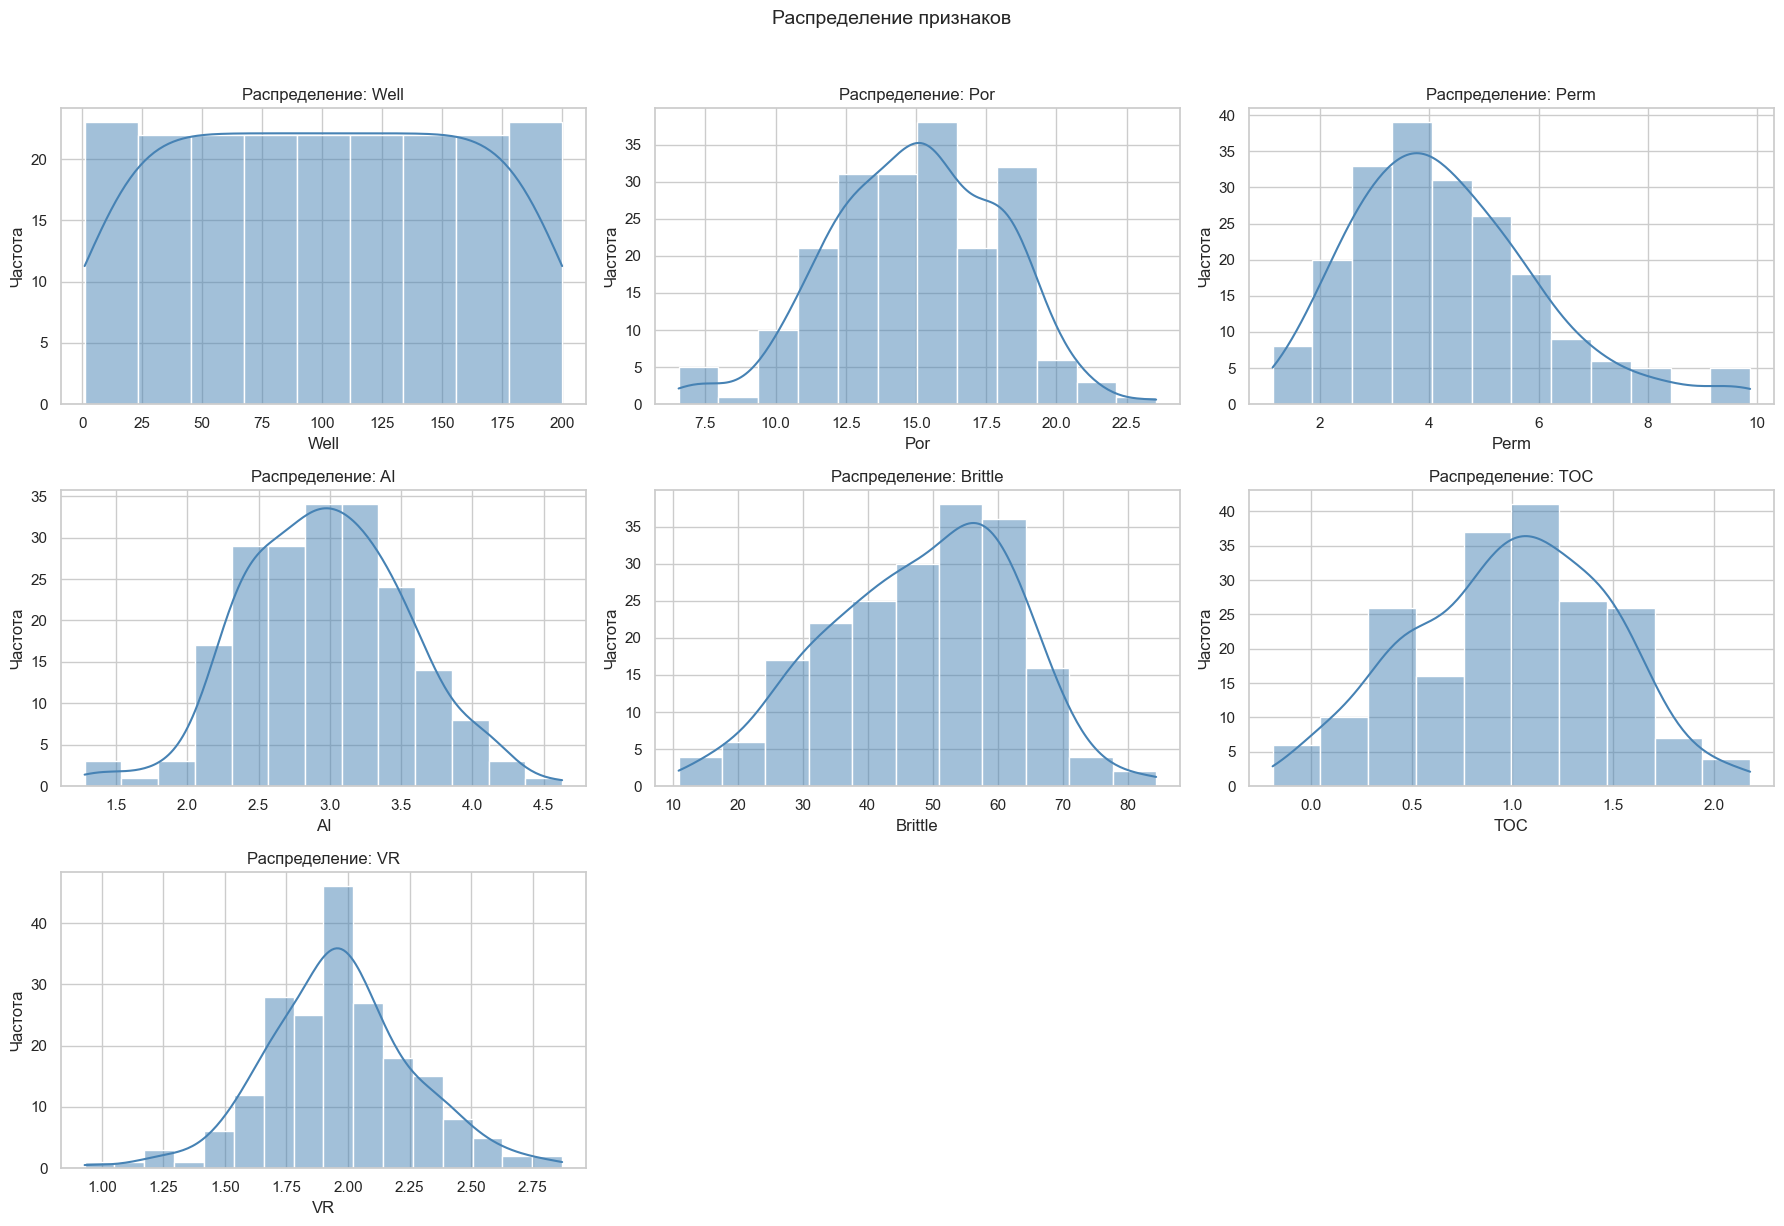

In [129]:
sns.set_theme(style='whitegrid', palette='muted')
features = ['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']
target = 'Prod'
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    sns.histplot(data[feat], kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Распределение: {feat}', fontsize=12)
    ax.set_xlabel(feat)
    ax.set_ylabel('Частота')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Распределение признаков', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

>Вывод: у многих признаков распределение похоже на нормальное

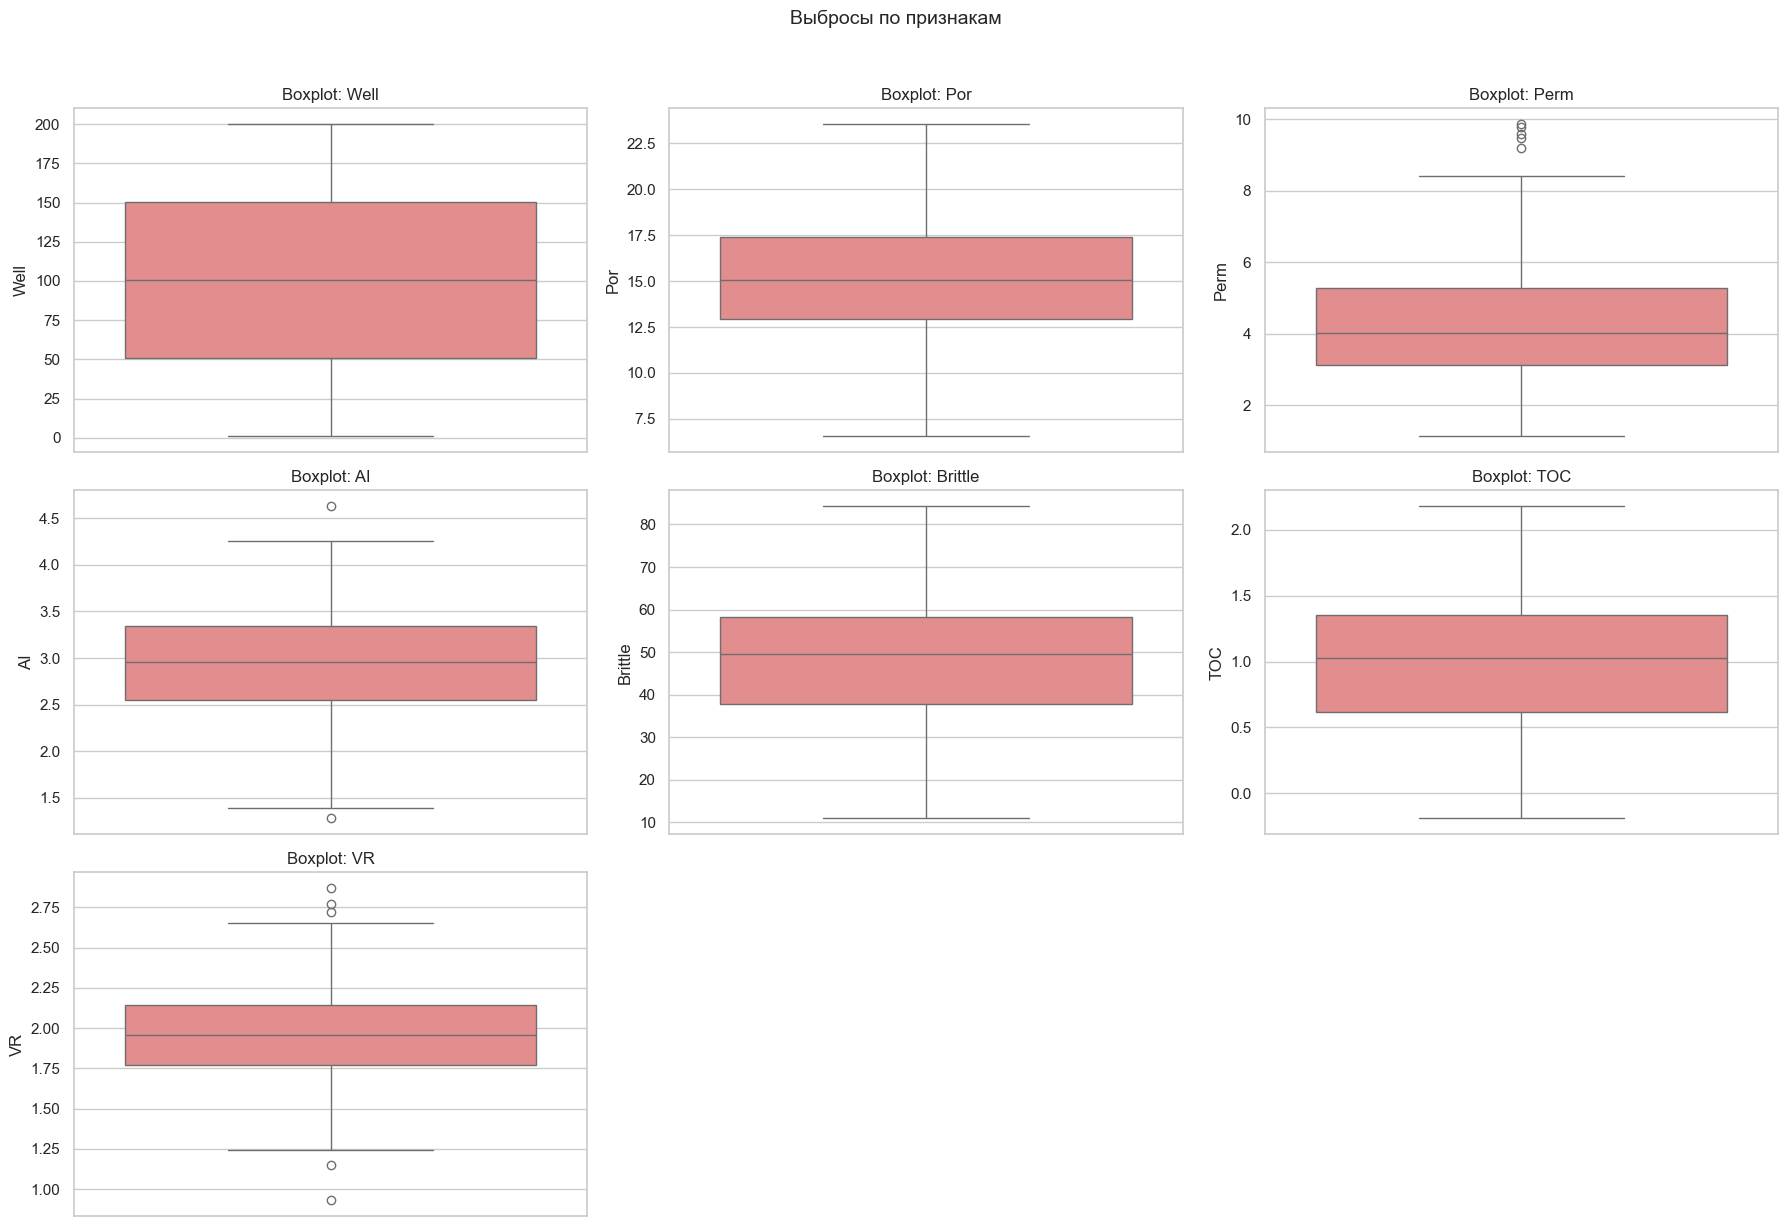

In [130]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    sns.boxplot(y=data[feat], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot: {feat}', fontsize=12)
    ax.set_ylabel(feat)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Выбросы по признакам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

>Вывод: выбросы присутствуют у следующих признаков: Perm, AI, VR

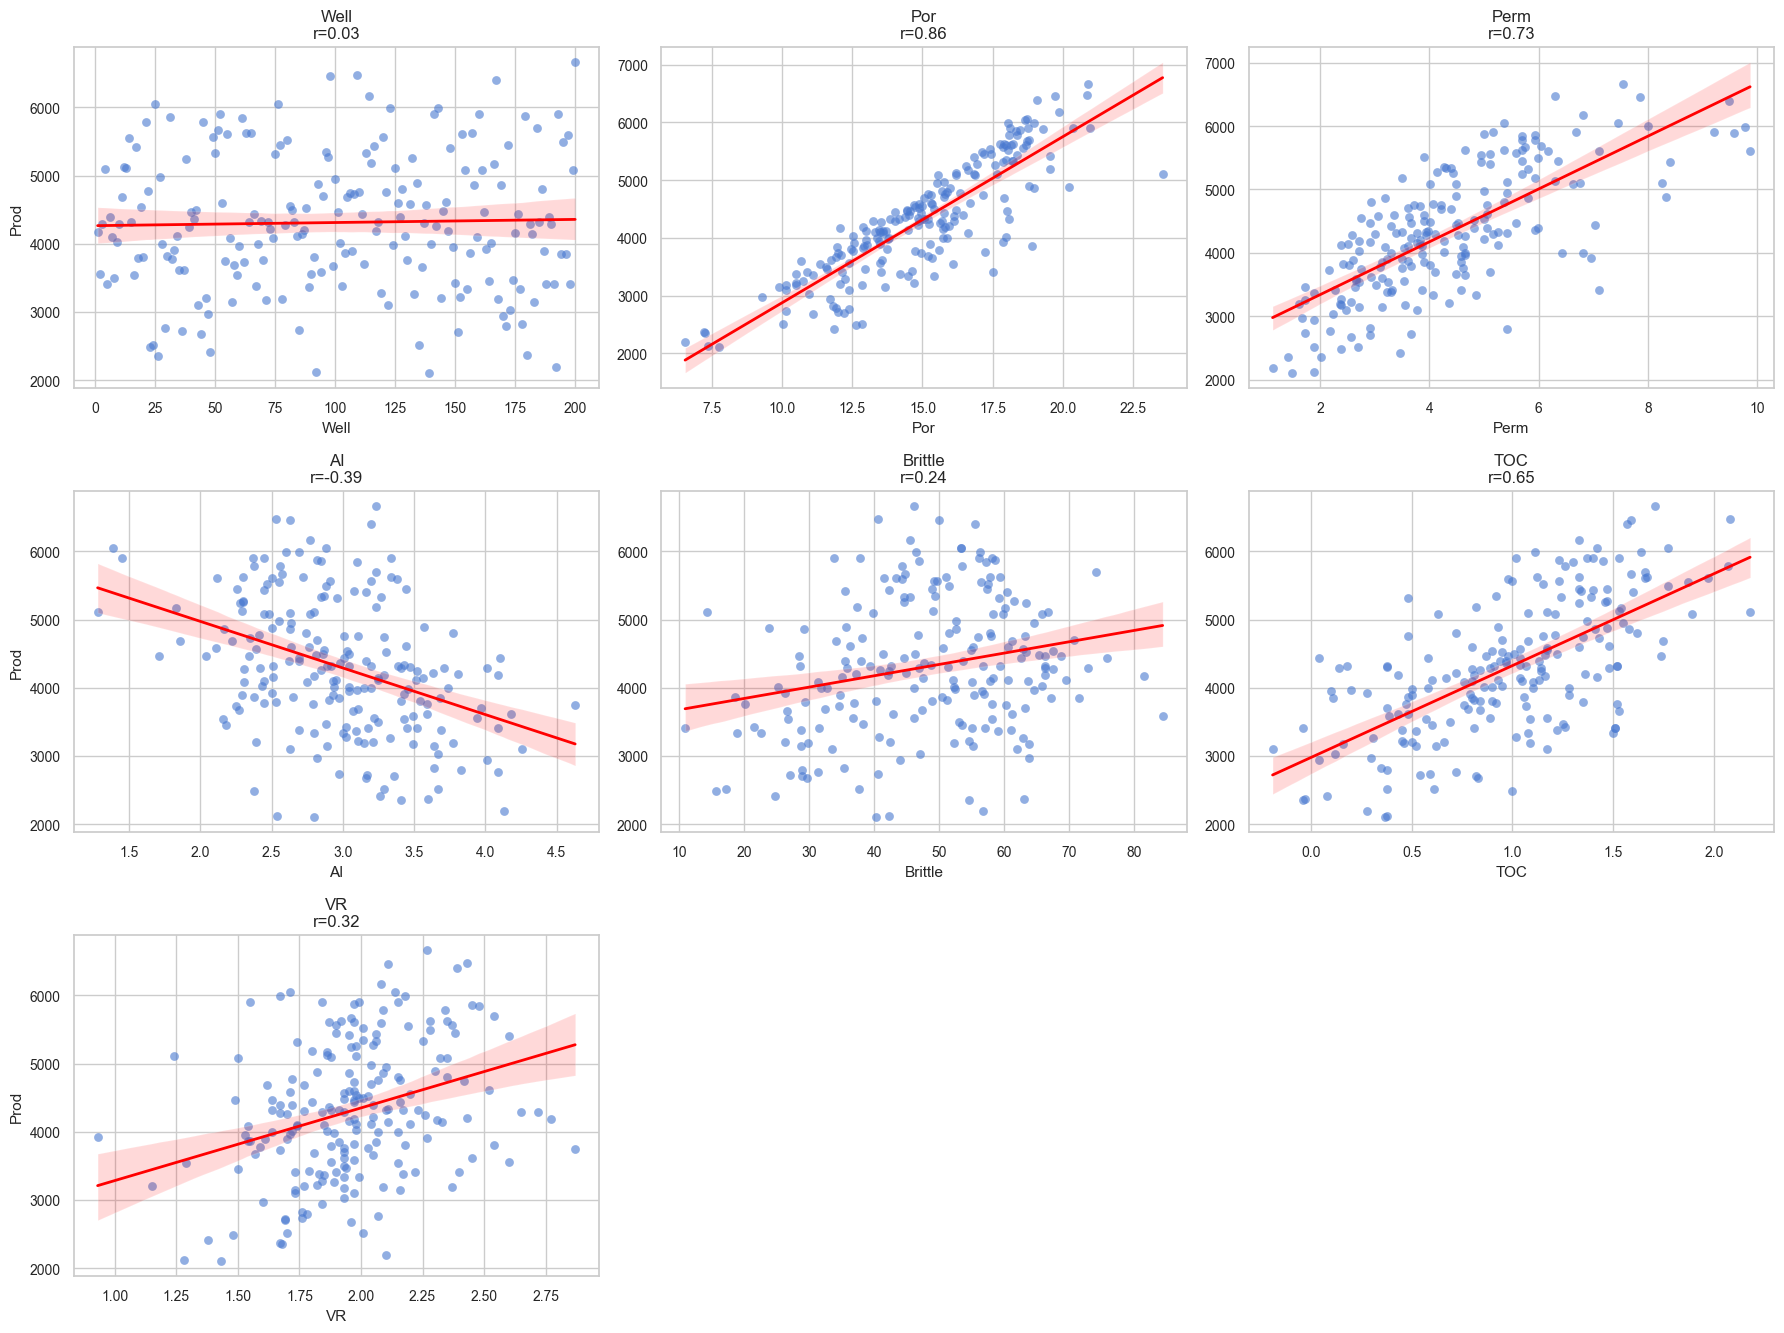

In [131]:
features = ['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']
target = 'Prod'

n_cols = 3  
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    
    sns.scatterplot(x=feat, y=target, data=data, alpha=0.6, s=40, linewidth=0, ax=ax)
    sns.regplot(x=feat, y=target, data=data, scatter=False, color='red', ax=ax, line_kws={'linewidth': 2})
    
    corr = data[feat].corr(data[target])
    ax.set_title(f"{feat}\nr={corr:.2f}", fontsize=12)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel(target if i % n_cols == 0 else "", fontsize=11)  # Y только у первого в каждом ряду
    ax.tick_params(labelsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

>Вывод: для призанков  Por, Perm и TOC заметна корреляция даже на этом этапе анализа

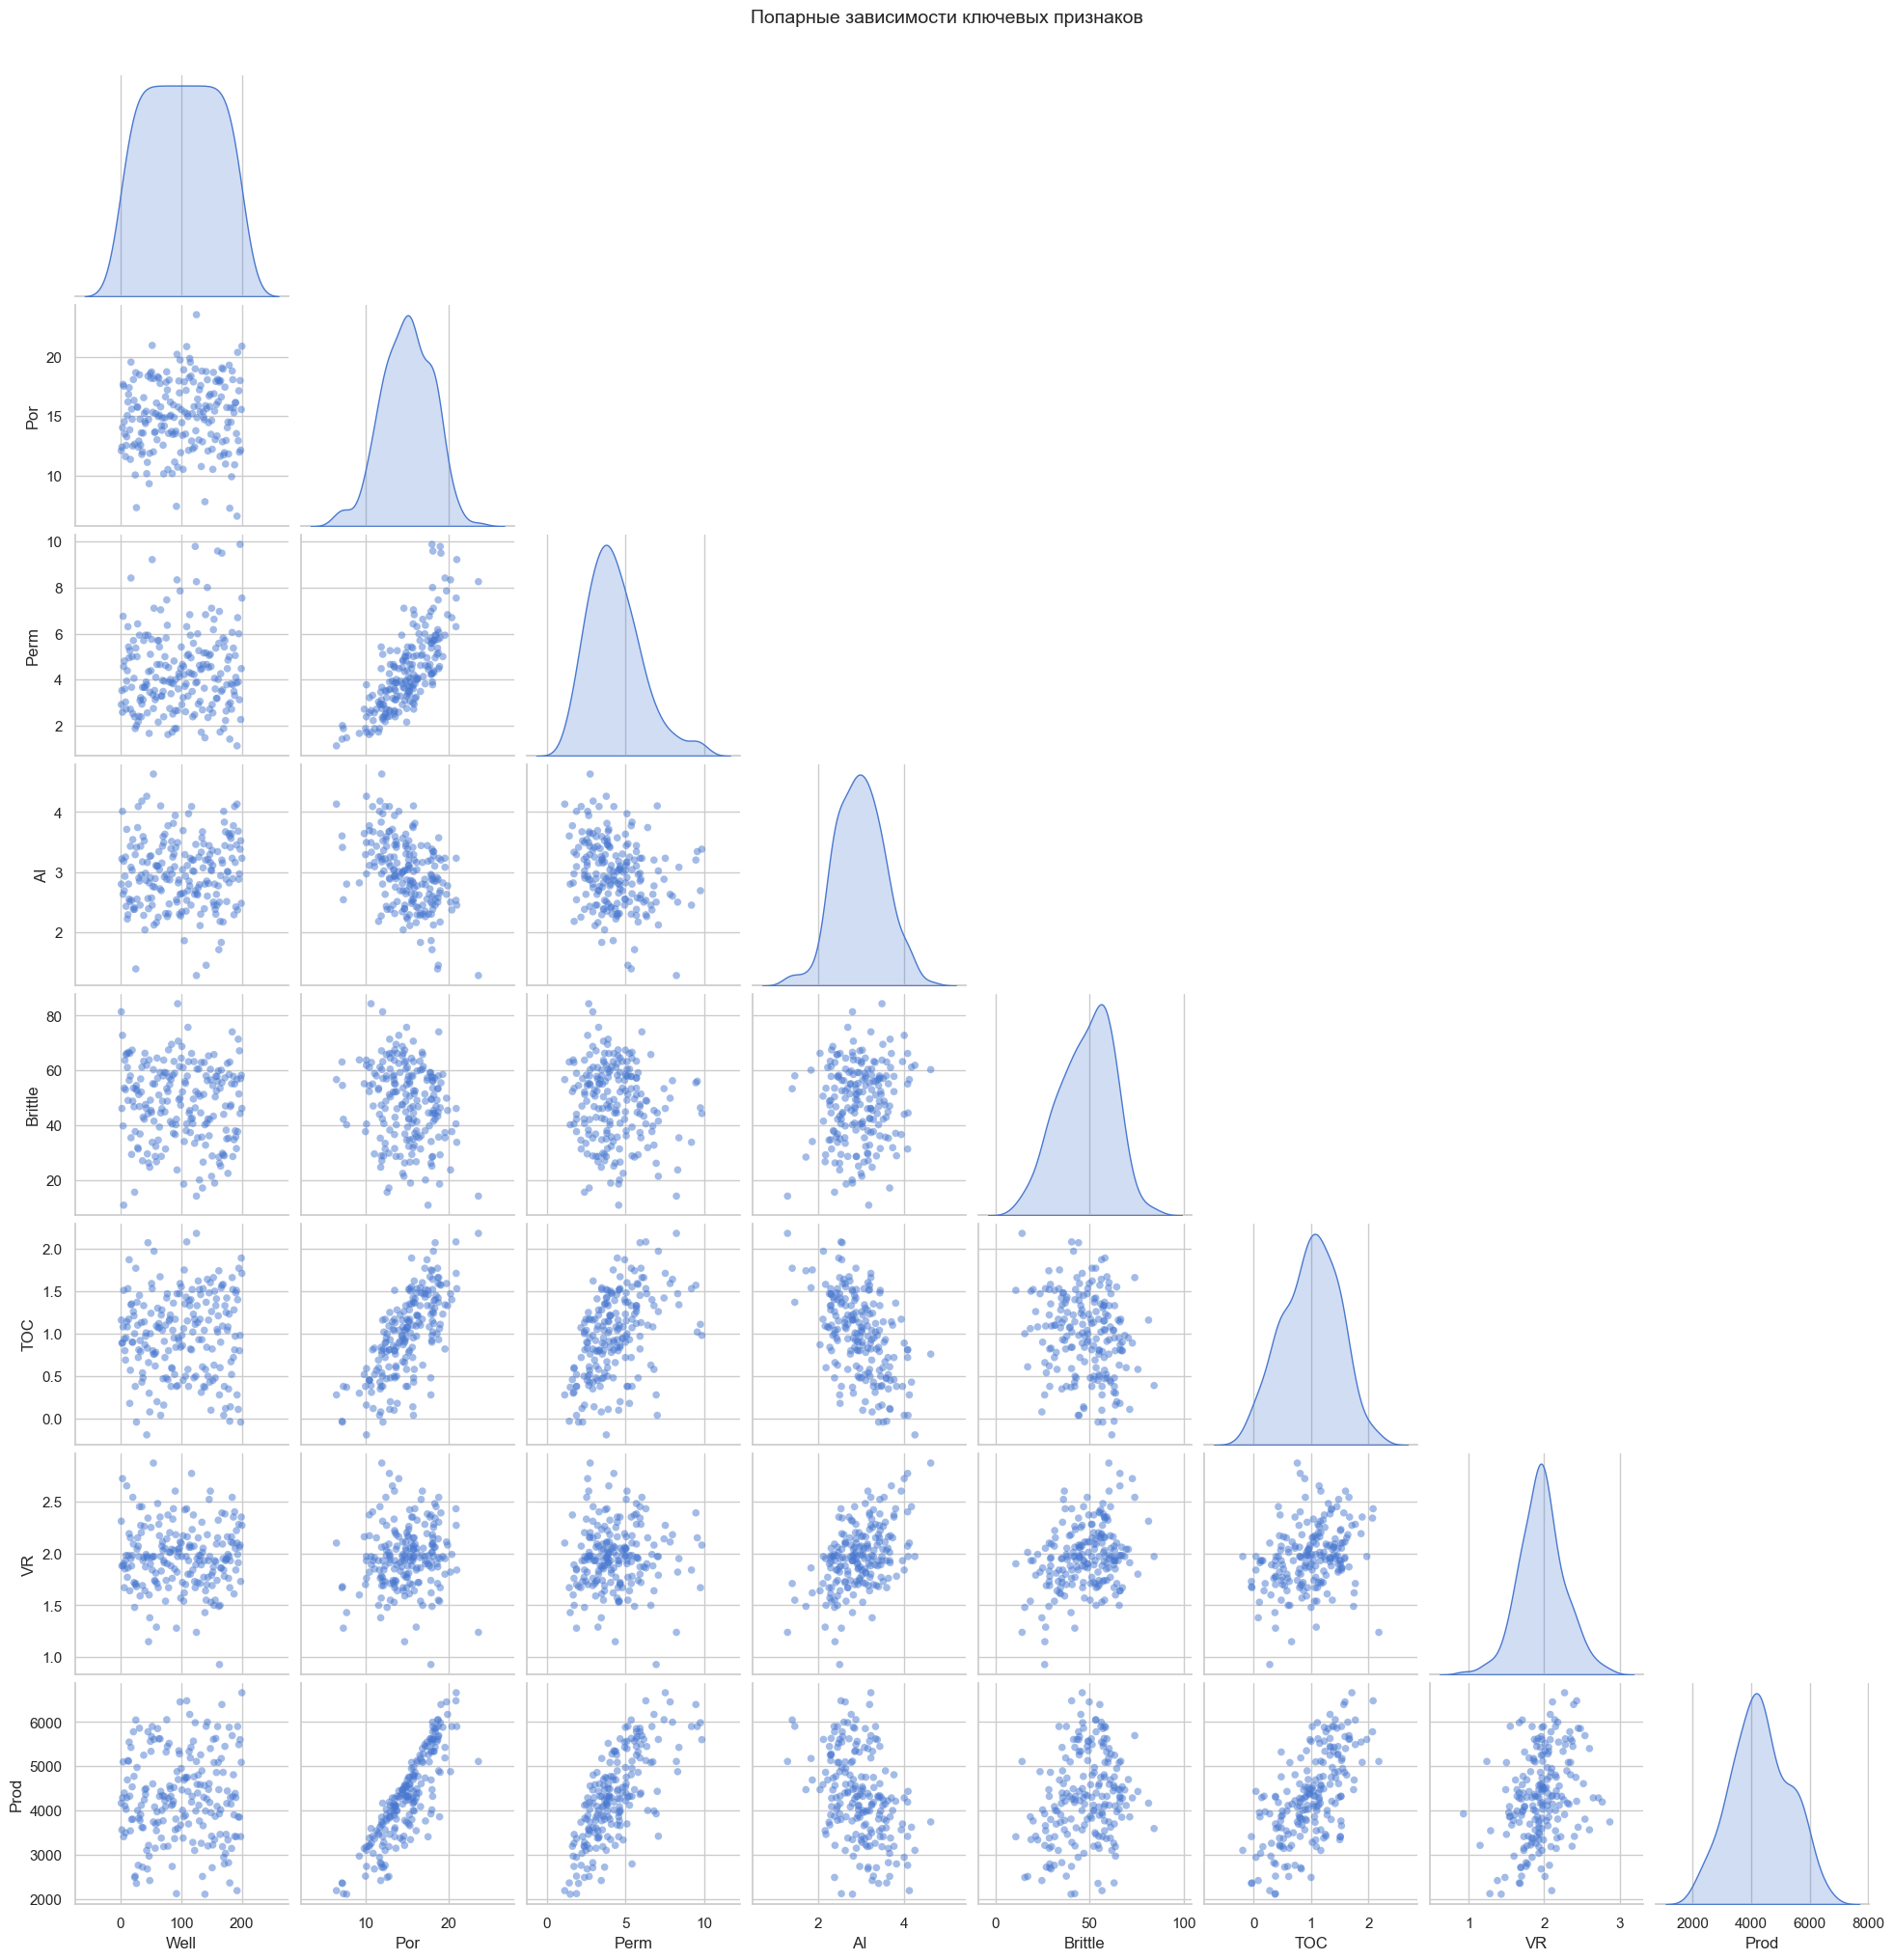

In [132]:
key_features = ['Well', 'Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', target]

sns.pairplot(
    data[key_features],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'none'},
    corner=True  # только нижний треугольник (без дублирования)
)
plt.suptitle('Попарные зависимости ключевых признаков', y=1.02, fontsize=14)
plt.show()

### Задание 5.1. (2 балла)

Постройте корреляционную матрицу факторов, включив в неё целевой признак. 

Для наглядности визуализируйте полученную матрицу с помощью тепловой карты. 

**Примечание.** *Для визуализации вы можете использовать любую из знакомых вам библиотек.*

На основе построенной корреляционной матрицы ответьте на следующий вопрос:

* Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для расчёта корреляционной матрицы;
    * приведён код для визуализации корреляционной матрицы в виде тепловой карты;
    * рассчитаны ранг и определитель корреляционной матрицы;
    * предоставлены обоснованные ответы на все поставленные вопросы. 

- Задание выполнено верно, но не учтено одно условие (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

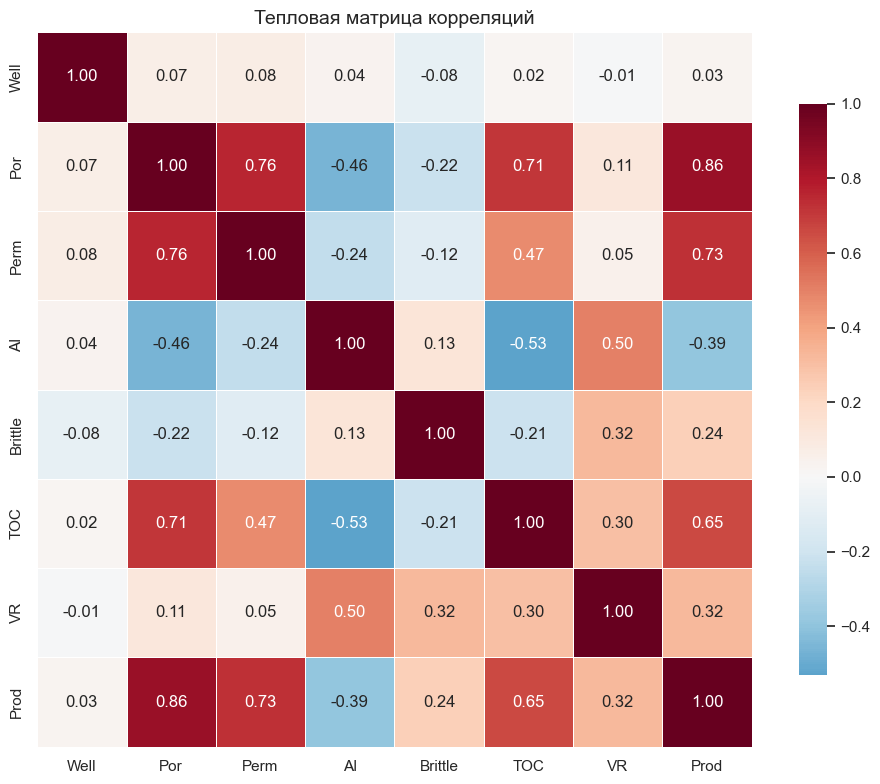

In [133]:
# Ваш код здесь
# Включаем целевую переменную в матрицу
all_cols = features + [target]
corr_matrix = data[all_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,           
    fmt='.2f',            
    cmap='RdBu_r',        
    center=0,             
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Тепловая матрица корреляций', fontsize=14)
plt.tight_layout()
plt.show()

In [134]:
# Получаем столбец корреляций с целевой переменной
corr_with_target = corr_matrix[target].drop(target)  # убираем саму целевую переменную

# Сортируем по абсолютному значению (чтобы видеть и сильную положительную, и сильную отрицательную связь)
strongest_corr = corr_with_target.abs().sort_values(ascending=False)

# Сила связи с целевой переменной
print("\nПолная корреляция (со знаком):")
print(corr_with_target.loc[strongest_corr.index])


Полная корреляция (со знаком):
Por        0.861910
Perm       0.727426
TOC        0.654445
AI        -0.390835
VR         0.323182
Brittle    0.237155
Well       0.026817
Name: Prod, dtype: float64


In [135]:
print('Ранг матрицы:\n',np.linalg.matrix_rank(corr_matrix))

Ранг матрицы:
 8


In [136]:
print('Определитель матрицы равен:\n',np.linalg.det(corr_matrix))

Определитель матрицы равен:
 0.0007299388072652095


> **Выводы**:
1. Сильнее всего с целевой переменной коррелируют следующие факторы в порядке убывания: Por 0.861910, Perm 0.727426, TOC 0.654445
2. Корреляционная матрица является плохо обусловенной - её опредитель близок к нулю
3. Чистой коллинеарности в матрице нет - факторы линейно не зависимы друг от друга. 
4. В связи с тем, что определитель матрицы близок к нулю и ранг матрицы максимален и равен 8 (количество признаков), это сигнализирует о наличии скрытой мультиколлинеарности
5. Модель классической линейной регрессии по методу наименьших квадратов в данном случае не применима из-за потенциальной вырожденности матрицы корреляций и близости ее определителя к нулю. Построение модели линейной регрессии на таких данных даст неадекватные коэффициенты регрессии, которым нельзя будет доверять и интерпретировать. Необходимо применить методы избавления от мультиколлинеарности, такие как регуляризация, метод глваных компонени или метод сингулярного разложения


### Задание 5.2. (2 балла)

Создайте матрицу наблюдений `X` и вектор правильных ответов `y`. В качестве факторов для матрицы наблюдений возьмите все имеющиеся в данных признаки. 

Постройте модель линейной регрессии по методу наименьших квадратов. Для этого воспользуйтесь матричной формулой МНК и инструментарием библиотеки numpy. 

Выведите на экран полученные оценки коэффициентов модели, округлённые до целого.

Приведите подробные выводы по полученным результатам, ответив на следующие вопросы:
* Есть ли в ваших данных признаки, которые, согласно модели, можно назвать неинформативными, то есть они не оказывают влияния на целевую переменную или оказывают шумовое влияние?
* Приведите интерпретацию нескольких (двух или трёх) коэффициентов полученной модели линейной регрессии.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для нахождения параметров модели линейной регрессии с помощью матричной формулы МНК;
    * на основе полученных параметров даны верные ответы на поставленные вопросы;
    * приведена корректная интерпретация нескольких коэффициентов полученной модели линейной регрессии.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

Формула аналитического решения по методу наименьших квадратов:
$$ \bar{w}=(X^TX)^{-1}X^Ty=QX^Ty$$

In [137]:
# Ваш код здесь
import numpy as np

#Составляем список факторов (исключили целевой столбец)
features = data.drop('Prod', axis=1).columns

#Составляем матрицу наблюдений X и вектор ответов y
X = data[features]
y = data['Prod']

#Вычислим OLS-оценку для коэффициентов
def linear_regression(X, y):
    #Создаём вектор из единиц
    ones = np.ones(X.shape[0])
    #Добавляем вектор к таблице первым столбцом
    X = np.column_stack([ones, X])
    #Вычисляем обратную матрицу Q
    Q = np.linalg.inv(X.T @ X)
    #Вычисляем вектор коэффициентов
    w = Q @ X.T @ y
    return w

#Вычисляем параметры линейной регрессии
w = linear_regression(X, y)
#Выводим вычисленные значения параметров в виде вектора, округленные до целого
print('Vector w: {}'.format(np.round(w)))


Vector w: [-1232.     0.   230.   116.  -365.    25.   -78.   785.]


> **Выводы**:
1. Неинформативные признаки

* ```Well``` — коэффициент равен 0. Модель считает этот признак абсолютно неинформативным: он не вносит никакого вклада в предсказание Prod. Это логично, если Well — это идентификатор скважины (категориальный признак, который не имеет числового смысла для линейной регрессии). Его следовало бы либо исключить, либо кодировать как категориальный (OneHot), но в линейной модели без предобработки он оказался «мёртвым» весом.

* ```Brittle``` — коэффициент 25, что заметно меньше остальных по модулю. Однако делать однозначный вывод о его неинформативности нельзя без учёта масштаба признака. 

Сравнивать «сырые» коэффициенты между признаками корректно только если они в одном масштабе. Без стандартизации нельзя утверждать, что признак с коэффициентом 25 менее важен, чем признак с коэффициентом 785. Для честного сравнения нужно привести признаки к единому масштабу (StandardScaler) и пересчитать модель — тогда коэффициенты будут сопоставимы.

2. Интерпретация коэффициентов
* ```Por``` (пористость) — коэффициент +230

При увеличении пористости на 1 единицу (при неизменных остальных признаках) добыча Prod возрастает на 230 единиц. Это согласуется с физическим смыслом: более пористая порода содержит больше флюида и лучше проводит его к скважине. Положительная связь также подтверждалась корреляционным анализом.

* ```AI``` (акустический импеданс) — коэффициент -365

При увеличении акустического импеданса на 1 единицу добыча снижается на 365 единиц (при прочих равных). Отрицательная связь означает, что более плотные/жёсткие породы (высокий AI) менее продуктивны — что также физически обоснованно: плотные породы труднее извлекать углеводороды.

* ```VR``` (коэффициент отражения витринита) — коэффициент +785

Самый большой по модулю коэффициент среди всех признаков. При увеличении VR на 1 единицу добыча растёт на 785 единиц. Однако здесь нужно быть осторожным: т.к. VR измеряется в малом диапазоне (например, 0,93–2,87), реальный вклад может быть скромнее, чем кажется по величине коэффициента. Тем не менее, направление связи — положительное, и по силе это один из ключевых факторов модели.

### Задание 5.3. (1 балл)

Теперь потренируемся строить предсказание для наблюдений целевой переменной. 

**а)** Постройте прогноз выработки газа для скважины со следующими параметрами:

```python
{
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
 }
```

Рассчитайте абсолютную ошибку построенного вами прогноза для предложенной скважины (в миллионах кубических футов в день), если известно, что на этой скважине производится `4748.315024` миллионов кубических футов газа в день. 

**б)** Постройте прогноз выработки газа для всех скважин из обучающего набора данных. Выберите метрику, по которой вы будете оценивать качество регрессионных моделей и сравнивать их между собой (можно использовать несколько метрик, но не более двух).

Рассчитайте значение выбранной метрики для вашей модели. Приведите интерпретацию полученного результата. 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для построения прогноза выработки газа на указанной скважине и рассчитана абсолютная ошибка прогноза для этой скважины;
    * выбрана корректная для поставленной задачи метрика (или метрики) оценки качества модели и приведён код для расчёта этой метрики на всём обучающем наборе данных;
    * приведена корректная интерпретация полученного результата.

- Задание выполнено верно, но не учтено одно из условий, или задание выполнено неверно (**0 баллов**).

In [138]:
# Ваш код здесь
# Параметры новой скважины (в том же порядке, что и в X)
new_well = np.array([1, 106.0, 15.32, 3.71, 3.29, 55.99, 1.35, 2.42])

# Прогноз
prediction = new_well @ w
print('Прогноз выработки газа: {:.6f}'.format(prediction))

Прогноз выработки газа: 4723.064054


In [139]:
y_true = 4748.315024
y_pred = 4723.064054

abs_error = abs(y_true - y_pred)
print('Абсолютная ошибка - {:.2f}'.format(abs_error),'млн куб. футов в день')

Абсолютная ошибка - 25.25 млн куб. футов в день


In [140]:
# Прогноз для всех скважин
def linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    Q = np.linalg.inv(X.T @ X)
    w = Q @ X.T @ y
    return w

w = linear_regression(X, y)

# Предсказания
ones = np.ones(X.shape[0])
X_with_bias = np.column_stack([ones, X])
y_pred = X_with_bias @ w

# Метрика 1: MAE — средняя абсолютная ошибка
mae = np.mean(np.abs(y - y_pred))

# Метрика 2: R² — коэффициент детерминации
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print('MAE: {:.2f}'.format(mae))
print('R²: {:.4f}'.format(r2))

MAE: 153.62
R²: 0.9599


> **Выводы:**
1. При фактической выработке ~4748 это относительная ошибка около 0,7% — довольно точный прогноз для линейной модели.
2. MAE показывает, на сколько в среднем ошибается модель при прогнозировании выработки газа. Например, если MAE ≈ 150, это значит, что типичный прогноз отклоняется от факта на 150 млн куб. футов в день. MAE удобен тем, что он в тех же единицах, что и целевая переменная — его легко объяснить инженерам или заказчику.
3. $R^2$ показывает, какую долю изменчивости целевой переменной модель смогла объяснить. $R^2=0.96$ означает, что модель объясняет 96% вариации выработки газа — это хороший результат для линейной регрессии на геологических данных.

### Задание 5.4. (1 балл)

Настало время анализа построенной модели. Посмотрите на коэффициенты и сравните их знаки со значениями выборочных корреляций между целевым признаком и факторами, которые вы нашли ранее.

Дайте развёрнутые ответы на следующие вопросы:

* Есть ли в вашей модели фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции? Например, корреляция говорит, что зависимость между фактором и целевой переменной прямая, а модель говорит обратное. Если таких факторов несколько, укажите их все.
* Как вы считаете, с чем связано полученное противоречие результатов?

**Критерии оценивания:**

- Задание выполнено верно, даны корректные развёрнутые ответы на все поставленные в задании вопросы (**1 балл**). 

- Задание выполнено неверно, даны некорректные ответы на один или несколько поставленных в задании вопросов (**0 баллов**).

In [141]:
# Ваш код здесь
# Парные корреляции Пирсона с целевой переменной
target = 'Prod'
features_real = [c for c in data.columns if c != target]

# Считаем корреляции с целевой переменной
corr_with_target = data[features_real].corrwith(data[target])

# Коэффициенты регрессии (без константы)
reg_coeffs = w[1:]  # пропускаем intercept

# Сравниваем знаки
sign_corr = np.sign(corr_with_target.values)
sign_reg = np.sign(reg_coeffs)

mismatch = sign_corr != sign_reg
print("Признаки с разными знаками корреляции и коэффициента регрессии:")
for feat, c_corr, c_reg, is_mismatch in zip(features, corr_with_target, reg_coeffs, mismatch):
    if is_mismatch:
        print(f"{feat}: корреляция = {c_corr:.3f}, коэффициент = {c_reg:.1f}")

Признаки с разными знаками корреляции и коэффициента регрессии:
TOC: корреляция = 0.654, коэффициент = -78.4


> **Выводы**:
1. TOC. У этого признака есть различия в знаке корреляции с целевой переменной и коэффициентом регрессии.
2. Причины расхождения связаны с мультиколлинеарностью с одним из признаков
3. Но где реально могут быть противоречия в знаках?
* TOC и VR

Это классические «кандидаты» на противоречие. TOC (содержание органического углерода) и VR (коэффициент отражения витринита) тесно связаны с термической зрелостью и часто сильно коррелируют друг с другом. Если в парной корреляции TOC имеет слабую отрицательную связь с Prod, а в регрессии его коэффициент становится более выраженным отрицательным — это не противоречие, а усиление эффекта за счёт контроля других переменных.

Если же в парной корреляции у TOC был положительный знак, а в регрессии он стал отрицательным — вот это уже противоречие, и оно почти наверняка вызвано мультиколлинеарностью с VR.
* Por и Perm

Пористость и проницаемость обычно сильно коррелируют. В парной корреляции оба признака могут показывать положительную связь с добычей. Но в регрессии один из них может получить меньший или даже отрицательный коэффициент, если модель «решает», что основную часть эффекта «забирает» другой признак. Это не ошибка, а перераспределение вклада.
* Well

Здесь важно: если Well — это номер скважины (категориальный идентификатор), то парная корреляция с Prod вообще не имеет физического смысла. Коэффициент 0 в регрессии говорит о том, что как непрерывная переменная он бесполезен. Для учёта скважин нужно использовать фиктивные переменные (OneHot) или смешанные модели.


### Задание 5.5. (2 балла)

* Исключите из данных сильно коррелированные между собой факторы. Под сильной корреляцией в данной задаче будем понимать значения выше `0.7`.

Выбирая, какой из коррелированных факторов оставить, руководствуйтесь коэффициентом корреляции с целевой переменной: оставляйте тот фактор, который больше всего коррелирует с целевой переменной (объёмом добычи газа).

* Также исключите из данных факторы, для которых корреляция с целевой переменной меньше `0.05`.

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого используйте матричную формулу и библиотеку numpy. Выведите значение полученных коэффициентов, округлённых до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте выбранную вами ранее метрику (или метрики). 

Дайте подробные ответы на следующие вопросы:

* Приведите интерпретацию нескольких полученных коэффициентов (двух или трёх). Сравните их значения с полученными ранее.
* Приведите интерпретацию полученных значений метрик. Сравните их значения с полученными ранее. 
* Удалось ли вам побороть противоречие коэффициентов линейной регрессии и коэффициентов корреляции?

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * отобраны верные факторы;
    * на основе отобранных факторов построена модель линейной регрессии с помощью матричной формулы МНК и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * даны ответы на все поставленные в задании вопросы.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено верно, не учтено несколько из условий (**0 баллов**).

In [142]:
# Ваш код здесь

#Сильные связи с целевой переменной
target = 'Prod'

# 1. Формируем список признаков: все колонки кроме целевой
features_clean = [c for c in data.columns if c != target]

# 2. Считаем корреляции с целевой переменной
corr_with_target = data[features_clean].corrwith(data[target])

# 3. Сортируем по силе связи (по модулю), но сохраняем знак
top_corr = corr_with_target.abs().sort_values(ascending=False)

# Восстанавливаем знаки, чтобы понимать направление связи
top_corr_signed = corr_with_target.loc[top_corr.index]

print("Топ признаков по силе связи с целевой переменной:")
print(top_corr_signed)

Топ признаков по силе связи с целевой переменной:
Por        0.861910
Perm       0.727426
TOC        0.654445
AI        -0.390835
VR         0.323182
Brittle    0.237155
Well       0.026817
dtype: float64


In [143]:
# 1. Матрица корреляций только по признакам (без target)
corr_features = data[features].corr()

# 2. Маска верхней треугольной части (чтобы не дублировать пары и убрать диагональ)
mask = np.triu(np.ones_like(corr_features, dtype=bool))
corr_masked = corr_features.mask(mask)

# 3. Превращаем в Series, убираем пропуски
corr_unstack = corr_masked.unstack().dropna()

# 4. Сортируем по модулю
corr_pairs = corr_unstack.abs().sort_values(ascending=False)

# 5. Убираем самокорреляции (r ≈ 1) и берём топ-10
strong_pairs = corr_pairs[corr_pairs < 0.999].head(10)

# 6. Красиво выводим пары
print("Самые сильные парные корреляции между признаками:")
for (feat1, feat2), val in strong_pairs.items():
    print(f"{feat1} — {feat2}: {val:.3f}")

Самые сильные парные корреляции между признаками:
Por — Perm: 0.761
Por — TOC: 0.712
AI — TOC: 0.532
AI — VR: 0.499
Perm — TOC: 0.472
Por — AI: 0.462
Brittle — VR: 0.318
TOC — VR: 0.299
Perm — AI: 0.240
Por — Brittle: 0.219


In [144]:
features = data.drop(['Prod','Perm','TOC', 'Well'], axis=1).columns

#Составляем матрицу наблюдений X и вектор ответов y
X = data[features]
y = data['Prod']

#Вычислим OLS-оценку для коэффициентов
def linear_regression(X, y):
    #Создаём вектор из единиц
    ones = np.ones(X.shape[0])
    #Добавляем вектор к таблице первым столбцом
    X = np.column_stack([ones, X])
    #Вычисляем обратную матрицу Q
    Q = np.linalg.inv(X.T @ X)
    #Вычисляем вектор коэффициентов
    w = Q @ X.T @ y
    return w
display(X.head())
#Вычисляем параметры линейной регрессии
w = linear_regression(X, y)
#Выводим вычисленные значения параметров в виде вектора, округленные до целого
print('Vector w: {}'.format(np.round(w)))

,Por,AI,Brittle,VR
0,12.08,2.80,81.40,2.31
1,12.38,3.22,46.17,1.88
2,14.02,4.01,72.80,2.72
3,17.67,2.63,39.81,1.88
4,17.52,3.18,10.94,1.90


Vector w: [-1835.   293.  -200.    28.   517.]


In [145]:
# Предсказания
ones = np.ones(X.shape[0])
X_with_bias = np.column_stack([ones, X])
y_pred = X_with_bias @ w

# Метрика 1: MAE — средняя абсолютная ошибка
mae = np.mean(np.abs(y - y_pred))

# Метрика 2: R² — коэффициент детерминации
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print('MAE: {:.2f}'.format(mae))
print('R²: {:.4f}'.format(r2))

MAE: 171.43
R²: 0.9452


> **Выводы**:
1. Убираем признак Perm, так как у него  корреляция с целевой переменной меньше, чем у Por
2. Убираем признак TOC, так как у него  корреляция с целевой переменной меньше, чем у Por
3. Убираем признак Well, так как у него  корреляция с целевой переменной 0.026817 и он в целом является ID скважины, а не признаком
4. Интерпретация коэффициентов
* ```Por``` (пористость) — коэффициент +230 (было)...+293 (стадл)

При увеличении пористости на 1 единицу (при неизменных остальных признаках) добыча Prod возрастает на 293 единицы. Это согласуется с физическим смыслом: более пористая порода содержит больше флюида и лучше проводит его к скважине. Положительная связь также подтверждалась корреляционным анализом.

* ```AI``` (акустический импеданс) — коэффициент -365 (было)....-200 (стало)

При увеличении акустического импеданса на 1 единицу добыча снижается на 200 единиц (при прочих равных). Отрицательная связь означает, что более плотные/жёсткие породы (высокий AI) менее продуктивны — что также физически обоснованно: плотные породы труднее извлекать углеводороды.

* ```VR``` (коэффициент отражения витринита) — коэффициент +785 (было)....+517 (стало)

Самый большой по модулю коэффициент среди всех признаков. При увеличении VR на 1 единицу добыча растёт на 517 единиц. Однако здесь нужно быть осторожным: т.к. VR измеряется в малом диапазоне (например, 0,93–2,87), реальный вклад может быть скромнее, чем кажется по величине коэффициента. Тем не менее, направление связи — положительное, и по силе это один из ключевых факторов модели.

5. Интерпретация метрик:
* MAE: 171.43 (было 153.62)  — средняя абсолютная ошибка в тех же единицах, что и целевая переменная (Prod). Если MAE уменьшился, значит, в среднем модель стала ошибаться меньше.
* R²: 0.9452 (было 0,9599) - Когда два признака сильно коррелируют (например, Por и Perm), каждый из них по отдельности может давать заметный вклад в $R^2$. Но этот вклад часто «дублируется»: они оба ловят одну и ту же часть вариации. При этом из‑за мультиколлинеарности коэффициенты нестабильны, а прогнозы хуже. Убрав один из пары, мы теряем часть «формального объяснения дисперсии» (поэтому $R^2$ падает), но при этом прогноз становится стабильнее и точнее в абсолютных значениях — отсюда снижение MAE. Это как раз тот случай, когда «более честная» модель даёт чуть меньший $R^2$, но лучшую обобщающую способность.

### Задание 5.6. (1 балл)

Наконец, давайте построим модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и сравним результаты её работы с теми, что нам удалось получить вручную. 

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого воспользуйтесь классом `LinearRegression` из библиотеки `sklearn`. Выведите значения полученных коэффициентов, округлённые до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте значение выбранной вами метрики (или метрик).

Сравните результаты библиотечной реализации с тем, что вы получили ранее. 

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов построена модель линейной регрессии из библиотеки sklearn и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * приведён вывод о соответствии результатов, полученных вручную и с помощью библиотеки.
- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [146]:
# Ваш код здесь
from sklearn import linear_model
#Создаём объект класса LinearRegression
lr = linear_model.LinearRegression()
#Обучаем модель — ищем параметры по МНК
lr.fit(X, y)
 
print('w0: {}'.format(lr.intercept_)) #свободный член w0
print('w: {}'.format(lr.coef_)) #остальные параметры модели w1, w2, ..., wm

w0: -1835.4464606940319
w: [ 293.03624565 -200.03091206   27.64098209  517.40272597]


In [147]:
from sklearn import metrics
#Делаем предсказание по всем признакам
y_predict = lr.predict(X)
#Рассчитываем MAE
print('MAE score: {:.3f}'.format(metrics.mean_absolute_error(y, y_predict)))
#Рассчитываем коэффициент детерминации
print('R2 score: {:.3f}'.format(metrics.r2_score(y, y_predict)))

MAE score: 171.431
R2 score: 0.945


> **Выводы**:
1. Модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и ее коэффициенты полностью совпали с матричным методом.
2. Метрики модели линейной регрессии из библиотеки `scikit-learn (sklearn)` также полностью совпали с  руным способом рассчета

## Практика: полиномиальная регрессия и регуляризация

Мы продолжаем работать над задачей от владельца компании «Газ-Таз-Ваз-Нефть» Василия.

Ранее мы построили модель линейной регрессии, которая прогнозирует выработку газа на скважине. Для этого мы с помощью матрицы корреляций и рассуждений отобрали некоррелированные, значимые для предсказания признаки. **Далее мы будем использовать именно их (см. задание 5.5).**

Мы хотим улучшить результат — уменьшить ошибку прогноза. Для этого мы воспользуемся моделью полиномиальной регрессии третьей степени. Однако теперь мы знаем, что полиномиальным моделям очень легко переобучиться под исходную выборку. Так как данных у нас не так много (всего 200 скважин), то для контроля качества модели мы будем использовать кросс-валидацию. 

Приступим! Выполните задания 8.1–8.5:


In [148]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

### Задание 8.1. (1 балл)

Стандаризируйте признаки с помощью `StandartScaler` из библиотеки `sklearn`. 

Затем сгенерируйте полиномиальные признаки третьего порядка на факторах, которые вы выбрали для обучения моделей. Для этого воспользуйтесь генератором полиномов `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` установите в значение `False`.

Выведите на экран, сколько факторов у вас получилось после генерации полиномиальных признаков.

**Важно:** стандартизацию необходимо произвести до генерации полиномиальных факторов!

Обучите модель линейной регрессии из библиотеки `sklearn` (`LinearRegression`) на полученных полиномиальных факторах.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов сгенерированы полиномиальные признаки третьего порядка;
    * построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).
- Задание выполнено неверно, не учтено одно или несколько из условий (**0 баллов**).

In [149]:
# Ваш код здесь
from sklearn.pipeline import Pipeline
# Создаём пайплайн: стандартизация → полиномиальные признаки → линейная регрессия
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('lr', LinearRegression())
])

# Показываем, сколько признаков получится после полиномов (на полном X для оценки размерности)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)
print(f'После генерации полиномиальных признаков получилось {X_poly.shape[1]} признаков')

# Кросс-валидация сразу по двум метрикам: MAE и R^2
cv_results = cross_validate(
    pipeline,
    X, y,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    cv=5,
    return_train_score=True
)

# MAE (убираем минус, потому что в sklearn это neg_*)
train_mae = -cv_results['train_neg_mae'].mean()
test_mae   = -cv_results['test_neg_mae'].mean()

# R^2 (уже положительный)
train_r2 = cv_results['train_r2'].mean()
test_r2  = cv_results['test_r2'].mean()

print(f'MAE на тренировочных фолдах: {train_mae:.2f}')
print(f'MAE на валидационных фолдах: {test_mae:.2f}')
print(f'R^2 на тренировочных фолдах: {train_r2:.3f}')
print(f'R^2 на валидационных фолдах: {test_r2:.3f}')

После генерации полиномиальных признаков получилось 34 признаков
MAE на тренировочных фолдах: 75.35
MAE на валидационных фолдах: 110.47
R^2 на тренировочных фолдах: 0.990
R^2 на валидационных фолдах: 0.975


> **Выводы:**
1. После отбора осталось 4 признака. Полиномиальное расширение 3 степени дает 34 признака. По отношению к числу наблюдений (200) - это много и провоцирует переобучение.
2. Модель отлично работает: $R^2$ =0.975 на валидации означает, что полиномиальная регрессия объясняет 97,5% дисперсии выработки газа. Это сильный результат. Однако есть признаки лёгкого переобучения, которые стоит учитывать.
3. MAE: 75.35 (train) vs 110.47 (test). Ошибка на валидации в 1,47 раза выше, чем на тренировке. Это разрыв умеренный, но он есть — модель чуть лучше подгоняется под обучающие данные, чем обобщает. В абсолютных единицах: в среднем прогноз на новых скважинах отклоняется на ~110 млн куб. футов/день.
4. Наблюдается умеренное переобучение, которое можно стабилизировать

### Задание 8.2. (2 балла)

Теперь попробуем воспользоваться линейной регрессией с регуляризацией. Для начала возьмём $L_1$-регуляризацию.

Обучите модель `Lasso` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Lasso), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [150]:
# Ваш код здесь

# Пайплайн: стандартизация → полиномы 3-й степени → Lasso
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('lasso', Lasso(max_iter=10000))
])

# Сетка значений alpha для подбора
param_grid = {
    'lasso__alpha': np.logspace(-3, 2, 30)  # от 0.001 до 100
}

# Подбираем alpha через GridSearchCV (оптимизируем по MAE)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5
)
grid_search.fit(X, y)

print(f'Оптимальное alpha: {grid_search.best_params_["lasso__alpha"]:.4f}')

# Обучаем финальный пайплайн с лучшим alpha
best_pipeline = grid_search.best_estimator_

# Кросс-валидация с двумя метриками
cv_results = cross_validate(
    best_pipeline,
    X, y,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    cv=5,
    return_train_score=True
)

train_mae = -cv_results['train_neg_mae'].mean()
test_mae  = -cv_results['test_neg_mae'].mean()
train_r2  = cv_results['train_r2'].mean()
test_r2   = cv_results['test_r2'].mean()

print(f'MAE на тренировочных фолдах: {train_mae:.2f}')
print(f'MAE на валидационных фолдах: {test_mae:.2f}')
print(f'R^2 на тренировочных фолдах: {train_r2:.3f}')
print(f'R^2 на валидационных фолдах: {test_r2:.3f}')

# Дополнительно: сколько коэффициентов Lasso обнулил
lasso_model = best_pipeline.named_steps['lasso']
n_zero = np.sum(lasso_model.coef_ == 0)
n_total = len(lasso_model.coef_)
print(f'Lasso обнулил {n_zero} из {n_total} коэффициентов')

Оптимальное alpha: 4.1753
MAE на тренировочных фолдах: 77.73
MAE на валидационных фолдах: 95.82
R^2 на тренировочных фолдах: 0.989
R^2 на валидационных фолдах: 0.982
Lasso обнулил 15 из 34 коэффициентов


> **Выводы**:
1. Lasso улучшил модель. Главная победа — MAE на валидации снизилась с 110.47 до 95.82 (на 13%), а разрыв между train и test заметно сузился. Регуляризация сработала именно так, как должна: чуть пожертвовала подгонкой под обучающие данные ради лучшего обобщения.
2. $R^2$ на валидации вырос: 0.975 → 0.982. Модель объясняет 98.2% дисперсии выработки газа — это отличный показатель. При этом на train $R^2$ практически не изменился (0.990 → 0.989), то есть потери в подгонке минимальны.
3. Lasso обнулил 15 из 34 коэффициентов. Почти половина полиномиальных признаков оказалась не нужна. $L_1$-регуляризация автоматически отобрала только те, которые реально вносят вклад в прогноз. Это упрощает модель и делает её интерпретируемее: вместо 34 признаков реально работают 19.
4. Оптимальное alpha = 4.18. Это умеренная регуляризация — не слишком слабая (иначе не обнулила бы 15 коэффициентов) и не слишком агрессивная (иначе MAE на test выросла бы). GridSearchCV нашёл хороший баланс

### Задание 8.3. (2 балла)

Проделаем то же самое с $L_2$-регуляризацией.

Обучите модель `Ridge` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

In [151]:
# Ваш код здесь

# Пайплайн: стандартизация → полиномы 3-й степени → Ridge
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('ridge', Ridge())
])

# Сетка значений alpha для подбора
param_grid = {
    'ridge__alpha': np.logspace(-3, 2, 30)  # от 0.001 до 100
}

# Подбираем alpha через GridSearchCV (оптимизируем по MAE)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5
)
grid_search.fit(X, y)

print(f'Оптимальное alpha: {grid_search.best_params_["ridge__alpha"]:.4f}')

# Обучаем финальный пайплайн с лучшим alpha
best_pipeline = grid_search.best_estimator_

# Кросс-валидация с двумя метриками
cv_results = cross_validate(
    best_pipeline,
    X, y,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    cv=5,
    return_train_score=True
)

train_mae = -cv_results['train_neg_mae'].mean()
test_mae  = -cv_results['test_neg_mae'].mean()
train_r2  = cv_results['train_r2'].mean()
test_r2   = cv_results['test_r2'].mean()

print(f'MAE на тренировочных фолдах: {train_mae:.2f}')
print(f'MAE на валидационных фолдах: {test_mae:.2f}')
print(f'R^2 на тренировочных фолдах: {train_r2:.3f}')
print(f'R^2 на валидационных фолдах: {test_r2:.3f}')

# Дополнительно: сколько коэффициентов близки к нулю 
ridge_model = best_pipeline.named_steps['ridge']
n_near_zero = np.sum(np.abs(ridge_model.coef_) < 0.01)
n_total = len(ridge_model.coef_)
print(f'Ridge: {n_near_zero} из {n_total} коэффициентов близки к нулю (|w| < 0.01)')

Оптимальное alpha: 0.2593
MAE на тренировочных фолдах: 75.46
MAE на валидационных фолдах: 110.03
R^2 на тренировочных фолдах: 0.990
R^2 на валидационных фолдах: 0.975
Ridge: 0 из 34 коэффициентов близки к нулю (|w| < 0.01)


> **Выводы**:
1. Ridge практически не изменил модель по сравнению с полиномиальной регрессией без регуляризации. Метрики почти идентичны, а оптимальное alpha оказалось очень маленьким (0.26) — то есть регуляризация почти не «включилась».
3. Оптимальное alpha = 0.26 — очень слабая регуляризация. GridSearchCV нашёл, что лучший результат достигается при почти нулевой регуляризации. Это значит, что $L_2$-штраф настолько мал, что коэффициенты практически не «сжимаются». Модель по сути осталась обычной полиномиальной регрессией.
3. Ridge не делает отбор признаков. В отличие от Lasso, Ridge не обнуляет коэффициенты — он лишь уменьшает их. При слабом alpha все 34 коэффициента остаются значимыми, включая те, что на самом деле дублируют друг друга. Модель не стала проще, а значит — не стала и устойчивее.
4. 0 из 34 коэффициентов близки к нулю. Подтверждает предыдущий пункт: Ridge не выдавил ни один «лишний» признак. Все полиномиальные члены остались в модели со своими весами, пусть и слегка уменьшенными.
5. Разрыв train/test остался 1.46× — почти как без регуляризации (1.47×). Регуляризация не уменьшила переобучение.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Ridge), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

### Задание 8.4. (2 балла)

Наконец, настало время комбинировать $L_1$ и $L_2$ -регуляризации.

Обучите модель `ElasticNet` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициенты регуляризации (`alpha` и `l1-ratio`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение метрики MAPE на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (ElasticNet), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [152]:
# Ваш код здесь

# Пайплайн: стандартизация → полиномы 3-й степени → ElasticNet
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('elasticnet', ElasticNet(max_iter=20000))
])

# Сетка для двух гиперпараметров
param_grid = {
    'elasticnet__alpha': np.logspace(-3, 2, 15),       # 15 значений от 0.001 до 100
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 9)  # от почти Ridge до почти Lasso
}

# Подбираем гиперпараметры (оптимизируем по MAE)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X, y)

print(f'Оптимальное alpha: {grid_search.best_params_["elasticnet__alpha"]:.4f}')
print(f'Оптимальное l1_ratio: {grid_search.best_params_["elasticnet__l1_ratio"]:.2f}')

# Финальный пайплайн с лучшими гиперпараметрами
best_pipeline = grid_search.best_estimator_

# Кросс-валидация с двумя метриками: MAE и R^2
cv_results = cross_validate(
    best_pipeline,
    X, y,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    cv=5,
    return_train_score=True
)

train_mae = -cv_results['train_neg_mae'].mean()
test_mae  = -cv_results['test_neg_mae'].mean()
train_r2  = cv_results['train_r2'].mean()
test_r2   = cv_results['test_r2'].mean()

print(f'MAE на тренировочных фолдах: {train_mae:.2f}')
print(f'MAE на валидационных фолдах: {test_mae:.2f}')
print(f'R^2 на тренировочных фолдах: {train_r2:.3f}')
print(f'R^2 на валидационных фолдах: {test_r2:.3f}')

# Сколько коэффициентов обнулил ElasticNet
en_model = best_pipeline.named_steps['elasticnet']
n_zero = np.sum(en_model.coef_ == 0)
n_total = len(en_model.coef_)
print(f'ElasticNet обнулил {n_zero} из {n_total} коэффициентов')

Оптимальное alpha: 0.0118
Оптимальное l1_ratio: 0.90
MAE на тренировочных фолдах: 75.37
MAE на валидационных фолдах: 109.89
R^2 на тренировочных фолдах: 0.990
R^2 на валидационных фолдах: 0.975
ElasticNet обнулил 0 из 34 коэффициентов


> **Выводы**:
ElasticNet почти не улучшил ситуацию по сравнению с базовой полиномиальной регрессией: 
* MAE test: 109.89 (было 110.47) — улучшение на 0.5%, то есть практически нулевое.
* $R^2$ test: 0.975 — ровно как у полиномиальной модели без регуляризации.
* Разрыв train/test остался примерно тем же: MAE train = 75.37, MAE test = 109.89 → разрыв в 1.46×.

При этом:
* alpha = 0.0118 — очень слабая регуляризация.
* l1_ratio = 0.90 — модель по сути «почти Lasso», но 0 из 34 коэффициентов обнулено — то есть отбора признаков не произошло.

### Задание 8.5. (1 балл)

Завершением вашей работы будет сводная таблица результатов, которую вы представите на презентации заказчику Василию.

Составьте таблицу (DataFrame) со следующими столбцами (имена столбцов выберите самостоятельно):
* Наименование модели.
* Гиперпараметры (коэффициенты регуляризации, если таковые имеются), если нет — оставьте ячейку пустой.
* Использовались ли полиномиальные признаки при построении модели (Да/Нет или True/False).
* Значение выбранной метрики на тренировочных фолдах при кросс-валидации модели.
* Значение выбранной метрики на валидационных фолдах при кросс-валидации модели.

Сделайте финальный вывод по проделанной работе. Какая линейная модель из тех, что мы рассмотрели, показала наилучший результат с точки зрения качества на валидационных фолдах, а также с точки зрения переобученности?

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * верно составлена сводная таблица итоговых результатов построенных ранее моделей с указанными в задании столбцами;
    * приведены итоговые выводы по проделанной работе, указано, какая из рассмотренных моделей показала наилучший результат.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [153]:
# Ваш код здесь

results = pd.DataFrame([
    {
        'Модель': 'Линейная регрессия (OLS)',
        'Гиперпараметры': '',
        'Полиномиальные признаки': 'Нет',
        'MAE train (CV)': None,
        'MAE test (CV)': None,
        'R² train (CV)': None,
        'R² test (CV)': None,
        'Примечание': 'Кросс-валидация не проводилась; метрики считались на обучающей выборке'
    },
    {
        'Модель': 'Полиномиальная регрессия (degree=3)',
        'Гиперпараметры': '',
        'Полиномиальные признаки': 'Да',
        'MAE train (CV)': 75.35,
        'MAE test (CV)': 110.47,
        'R² train (CV)': 0.990,
        'R² test (CV)': 0.975,
        'Примечание': 'Без регуляризации; 34 признака'
    },
    {
        'Модель': 'Lasso (degree=3)',
        'Гиперпараметры': 'alpha=4.1753',
        'Полиномиальные признаки': 'Да',
        'MAE train (CV)': 77.73,
        'MAE test (CV)': 95.82,
        'R² train (CV)': 0.989,
        'R² test (CV)': 0.982,
        'Примечание': 'Обнулено 15 из 34 коэффициентов'
    },
    {
        'Модель': 'Ridge (degree=3)',
        'Гиперпараметры': 'alpha=0.2593',
        'Полиномиальные признаки': 'Да',
        'MAE train (CV)': 75.46,
        'MAE test (CV)': 110.03,
        'R² train (CV)': 0.990,
        'R² test (CV)': 0.975,
        'Примечание': 'Обнулено 0 из 34 коэффициентов'
    },
    {
        'Модель': 'ElasticNet (degree=3)',
        'Гиперпараметры': 'alpha=0.0118, l1_ratio=0.90',
        'Полиномиальные признаки': 'Да',
        'MAE train (CV)': 75.37,
        'MAE test (CV)': 109.89,
        'R² train (CV)': 0.990,
        'R² test (CV)': 0.975,
        'Примечание': 'Обнулено 0 из 34 коэффициентов'
    }
])

# Выводим таблицу
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(results.to_string(index=False))

                             Модель              Гиперпараметры Полиномиальные признаки  MAE train (CV)  MAE test (CV)  R² train (CV)  R² test (CV)                                                             Примечание
           Линейная регрессия (OLS)                                                 Нет             NaN            NaN            NaN           NaN Кросс-валидация не проводилась; метрики считались на обучающей выборке
Полиномиальная регрессия (degree=3)                                                  Да           75.35         110.47          0.990         0.975                                         Без регуляризации; 34 признака
                   Lasso (degree=3)                alpha=4.1753                      Да           77.73          95.82          0.989         0.982                                        Обнулено 15 из 34 коэффициентов
                   Ridge (degree=3)                alpha=0.2593                      Да           75.46         110.03      

>**Финальный вывод**:

Lasso — лучший выбор среди всех протестированных моделей:
* минимальная MAE на валидации (95.82),
* максимальный $R^2$ на валидации (0.982),
* наименьший разрыв train/test (1.23×),
* автоматический отбор признаков: 19 работающих вместо 34.
* Остальные модели с полиномами (Ridge, ElasticNet, без регуляризации) показали практически одинаковые результаты — регуляризация в них оказалась слишком слабой, чтобы улучшить обобщение. 